## Data Generation

Generate and inspect synthetic SKU-region sales, product, pricing, promotion, and holiday data.

In [7]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

c:\Users\sajal\OneDrive\Desktop\supply-chain


In [8]:
import pandas as pd
import matplotlib.pyplot as plt

sales = pd.read_csv(PROJECT_ROOT / "data/raw/sales_history.csv", parse_dates=["date"])
products = pd.read_csv(PROJECT_ROOT / "data/raw/products.csv")
print("Sales shape:", sales.shape)
print("Products shape:", products.shape)
display(sales.head())
display(products)

Sales shape: (54800, 9)
Products shape: (10, 4)


,date,sku,product,pack_size,region,units_sold,price,promotion,is_holiday
0,2023-01-01,BB250,Bharat Cola,250ml,North,464,24.0,0,0
1,2023-01-01,BB250,Bharat Cola,250ml,South,623,24.0,0,0
2,2023-01-01,BB250,Bharat Cola,250ml,East,428,24.0,0,0
3,2023-01-01,BB250,Bharat Cola,250ml,West,576,24.0,0,0
4,2023-01-01,BB250,Bharat Cola,250ml,Central,426,24.0,0,0


,sku,product,pack_size,base_price
0,BB250,Bharat Cola,250ml,24
1,BB500,Bharat Cola,500ml,35
2,BB1000,Bharat Cola,1L,55
3,LM250,Lemon Blast,250ml,22
4,LM500,Lemon Blast,500ml,32
5,OR500,Orange Rush,500ml,34
6,OR1000,Orange Rush,1L,52
7,EN250,Energy Max,250ml,48
8,EN500,Energy Max,500ml,72
9,WT1000,Bharat Water,1L,20


In [9]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 54800 entries, 0 to 54799
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        54800 non-null  datetime64[us]
 1   sku         54800 non-null  str           
 2   product     54800 non-null  str           
 3   pack_size   54800 non-null  str           
 4   region      54800 non-null  str           
 5   units_sold  54800 non-null  int64         
 6   price       54800 non-null  float64       
 7   promotion   54800 non-null  int64         
 8   is_holiday  54800 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(4)
memory usage: 5.1 MB


In [10]:
print("Date range:", sales["date"].min(), "to", sales["date"].max())
print("SKUs:", sales["sku"].nunique())
print("Regions:", sales["region"].nunique())
display(sales.isna().sum())

Date range: 2023-01-01 00:00:00 to 2025-12-31 00:00:00
SKUs: 10
Regions: 5


date          0
sku           0
product       0
pack_size     0
region        0
units_sold    0
price         0
promotion     0
is_holiday    0
dtype: int64

,sku,region,units_sold
49,WT1000,West,1209558
48,WT1000,South,1142882
14,BB500,West,1116817
13,BB500,South,1062547
47,WT1000,North,1046923
46,WT1000,East,992032
12,BB500,North,976234
45,WT1000,Central,939611
11,BB500,East,925313
10,BB500,Central,867460


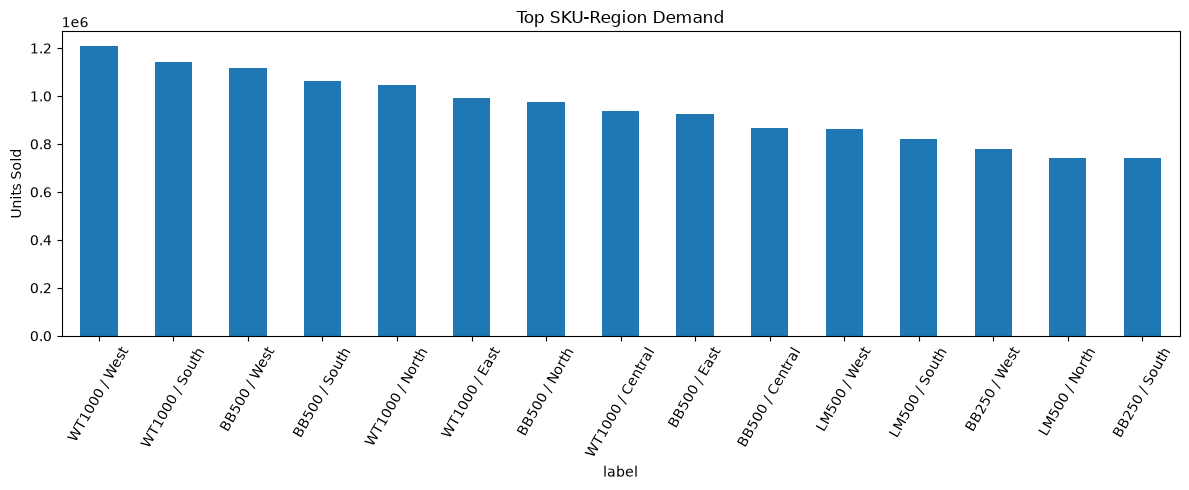

In [11]:
sku_region_demand = (sales.groupby(["sku", "region"], as_index=False)["units_sold"].sum().sort_values("units_sold", ascending=False))
display(sku_region_demand.head(15))

plt.figure(figsize=(12, 5))
sku_region_demand.head(15).assign(label=lambda x: x["sku"] + " / " + x["region"]).plot.bar(x="label", y="units_sold", legend=False, ax=plt.gca())
plt.title("Top SKU-Region Demand")
plt.ylabel("Units Sold")
plt.xticks(rotation=60)
plt.tight_layout()
plt.show()